In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ks_2samp

In [50]:
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [55]:
t33 = df['Time'].quantile(0.33)
t66 = df['Time'].quantile(0.66)

df1 = df[df['Time'] <= t66]                    
df2 = df[df['Time'] > t66]

### Drift : Répartition des classes

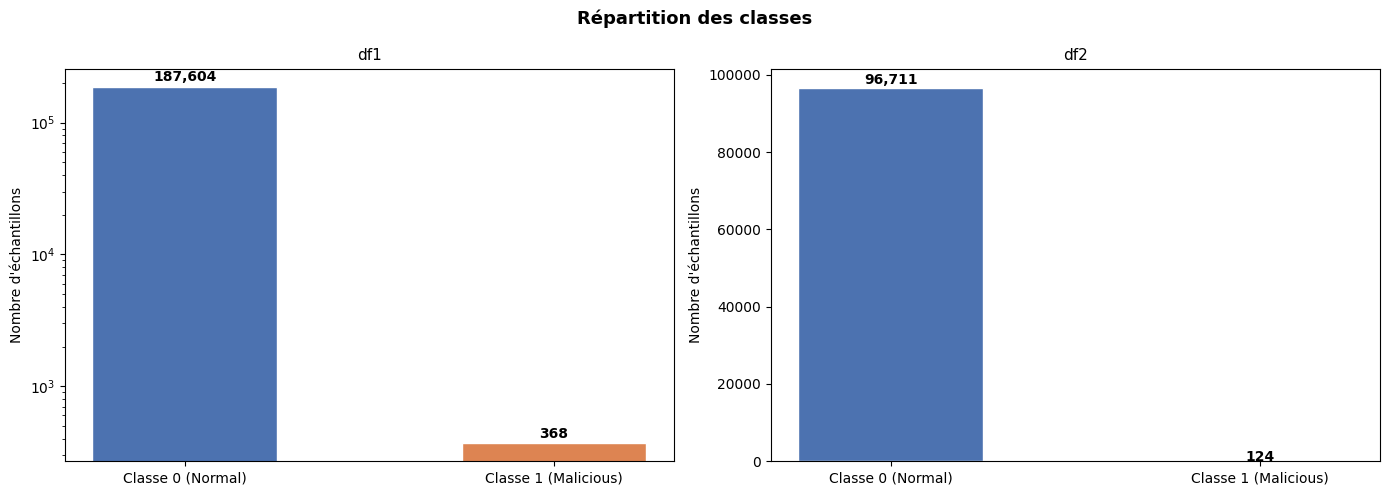

In [57]:
labels = ['Classe 0 (Normal)', 'Classe 1 (Malicious)']

df1_counts = df1["Class"].value_counts()
df2_counts = df2["Class"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Répartition des classes', fontsize=13, fontweight='bold')

colors = ['#4C72B0', '#DD8452']
x = np.arange(len(labels))
width = 0.5

bars1 = axes[0].bar(x, df1_counts, width=width, color=colors, edgecolor='white')
axes[0].set_title('df1', fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Nombre d'échantillons")
axes[0].set_yscale('log')  
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(x, df2_counts, width=width, color=colors, edgecolor='white')
axes[1].set_title('df2', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Nombre d'échantillons")
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')


plt.tight_layout()
plt.show()

### Drift par feature

In [59]:
stats = []
for col in df.columns:
    stat, p = ks_2samp(df1[col], df2[col])
    stats.append(stat)
    print(f"{col}: stat={stat:.3f}, p={p:.4f}")

Time: stat=1.000, p=0.0000
V1: stat=0.322, p=0.0000
V2: stat=0.034, p=0.0000
V3: stat=0.422, p=0.0000
V4: stat=0.149, p=0.0000
V5: stat=0.192, p=0.0000
V6: stat=0.103, p=0.0000
V7: stat=0.108, p=0.0000
V8: stat=0.104, p=0.0000
V9: stat=0.048, p=0.0000
V10: stat=0.052, p=0.0000
V11: stat=0.173, p=0.0000
V12: stat=0.098, p=0.0000
V13: stat=0.056, p=0.0000
V14: stat=0.093, p=0.0000
V15: stat=0.201, p=0.0000
V16: stat=0.012, p=0.0000
V17: stat=0.087, p=0.0000
V18: stat=0.069, p=0.0000
V19: stat=0.052, p=0.0000
V20: stat=0.113, p=0.0000
V21: stat=0.133, p=0.0000
V22: stat=0.166, p=0.0000
V23: stat=0.150, p=0.0000
V24: stat=0.070, p=0.0000
V25: stat=0.241, p=0.0000
V26: stat=0.062, p=0.0000
V27: stat=0.068, p=0.0000
V28: stat=0.273, p=0.0000
Amount: stat=0.019, p=0.0000
Class: stat=0.001, p=1.0000


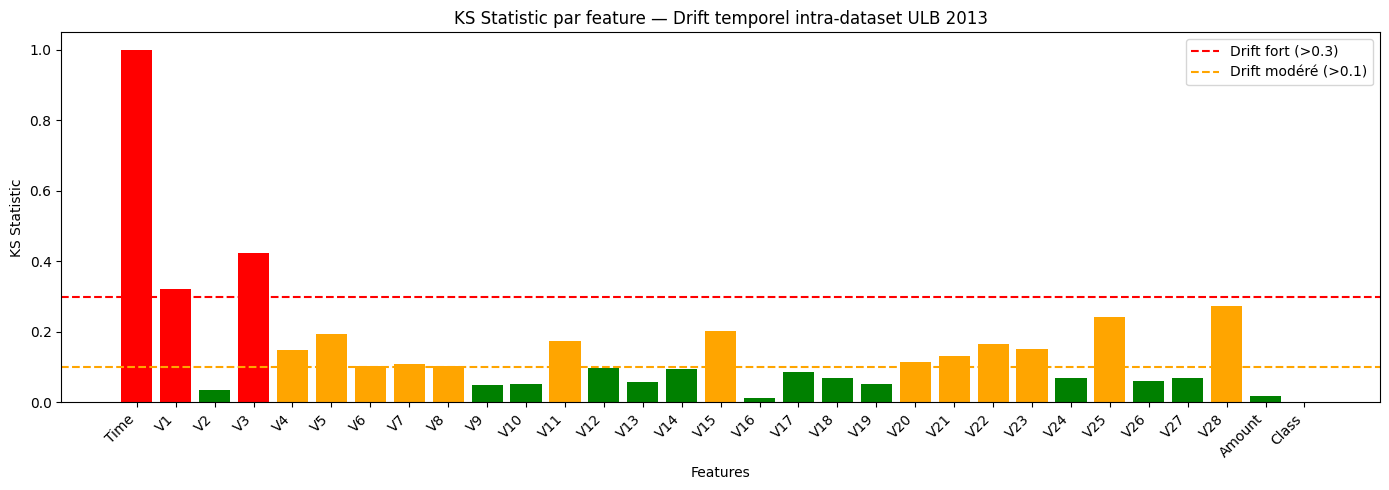

In [ ]:
features = list(df1.columns)
stats_array = np.array(stats)  

colors = ['red' if s > 0.3 else 'orange' if s > 0.1 else 'green'
          for s in stats_array]

plt.figure(figsize=(14, 5))
plt.bar(features, stats_array, color=colors) 
plt.axhline(0.3, color='red', linestyle='--', label='Drift fort (>0.3)')
plt.axhline(0.1, color='orange', linestyle='--', label='Drift modéré (>0.1)')
plt.title('KS Statistic par feature — Drift temporel intra-dataset ULB 2013')
plt.ylabel('KS Statistic')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('ks_drift.png', dpi=150)
plt.show()